# <span style="color:red"> **LSN - Esercitazione 10**
### <span style="color:green"> 22.05.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

### <span style="color:blue">**_Parallelizzazione dell'Algoritmo Genetico e Problema del Commesso Viaggiatore_**

Per ottimizzare l'utilizzo delle risorse computazionali e affrontare problemi di dimensioni maggiori, è possibile adottare tecniche di parallelizzazione del codice. Tra i vari paradigmi disponibili, il **Single Program Multiple Data** (SPMD) si distingue per la sua efficacia in contesti distribuiti. Questo approccio prevede l'esecuzione dello stesso programma su più nodi di calcolo, ciascuno dei quali elabora un sottoinsieme distinto dei dati. In un'architettura parallela basata su SPMD, ogni nodo è identificato univocamente da un rank, un valore numerico che ne determina il ruolo durante l'esecuzione. Grazie a questa distinzione, i nodi possono eseguire percorsi computazionali diversi pur condividendo lo stesso codice sorgente, adattando il comportamento in base al rank assegnato. Nell'ambito di questa esercitazione, è stata implementata la parallelizzazione dell'Algoritmo Genetico (GA), sviluppato nella precedente esercitazione, sfruttando la libreria **Message Passing Interface** (MPI). MPI permette di coordinare i nodi attraverso lo scambio di messaggi, facilitando operazioni come la distribuzione del carico di lavoro, la sincronizzazione e l'aggregazione dei risultati. \
\
Lo scopo di questa esercitazione è la risoluzione del **Problema del Commesso Viaggiatore** (TSP) applicato ai **110 capoluoghi di provincia italiani**, le cui coordinate geografiche (latitudine e longitudine) sono fornite nel file `cap_prov_ita.dat`. A tal fine, si sono effettuate **12** ricerche del miglior percorso indipendenti, ciascuna eseguita su un nodo diverso e denominata "continente". Ogni continente evolve autonomamente una propria popolazione di soluzioni, ottimizzando localmente il percorso tramite un Algoritmo Genetico (GA). Tuttavia, per ridurre il rischio di convergenza prematura (verso minimi locali) ed esplorare regioni diverse dello spazio delle soluzioni, è stato implementato un meccanismo di migrazione ciclica di individui tra i continenti. In particolare, ogni $N_{migr}$ generazioni, un numero prestabilito di individui ($n_{migranti}$) viene scambiato tra i nodi. Lo scambio avviene in modo anulare: ciascun continente invia i suoi migranti al nodo successivo e riceve individui dal nodo precedente, creando un flusso circolare di informazioni.

La struttura a classi del codice è analoga a quella realizzata per risolvere il TSP con Algoritmo Genetico senza parallelizzazione (Esercitazione 9); tuttavia, sono state apportate alcune modifiche alla classe `Popolazione`. Innanzitutto, è stato modificato il metodo `evolve(const arma::mat dist_matrix, int rank , int size)`: è stata aggiunta la dipendenza dal rank del core in uso, per rendere indipendenti le popolazioni di ciascun continente. Inoltre, oltre all'evoluzione del sistema per $n_{gen}$ generazioni, la funzione performa anche la migrazione circolare di $n_{migranti}$ ogni $N_{migr}$ generazioni. Si è poi modificato il metodo `initialize_pop(int npop, int ngen, arma::mat *dist_matrix)`, affinché ciascun processo MPI abbia un generatore di numeri casuali inizializzato diversamente.

Il cuore della parallelizzazione, tuttavia, è nel `main`, che gestisce effettivamente l'evoluzione parallela delle diverse popolazioni, e ha la seguente struttura:
- Inizializzazione di MPI, e rilevazione del numero totale di processi `world_size` e del rank del processo corrente `world_rank`;
- Lettura delle coordinate e costruzione della matrice delle distanze secondo norma $L^{(1)}$;
- Inizializzazione della popolazione: ogni processo inizializza indipendentemente la propria popolazione costituita da $npop$ elementi;
- Evoluzione della popolazione: ogni processo esegue un algoritmo genetico sulla propria popolazione locale tramite il metodo `evolve`, per un totale di $ngen$ generazioni;
- Selezione della miglior soluzione globale:
  * Ogni processo calcola la lunghezza del proprio percorso migliore.
  * Il rank 0 raccoglie tutte le lunghezze tramite `MPI_Gather`, poi seleziona la minima.
  * Se il miglior percorso non è sul rank 0, viene inviato al processo 0 tramite `MPI_Send`/`MPI_Recv`.
- Il processo 0 salva su file `global_best_route.dat` la sequenza di città corrispondente al percorso migliore trovato tra tutti i processi MPI, includendo un commento con la lunghezza complessiva;
- Si termina MPI.

**Parametri utilizzati:**

| Parametro         | Valore |
|-------------------|--------|
| $ngen$            | 1000   |
| $npop$            | 500   |
| $n_{\text{migranti}}$ | 30     |
| $N_{\text{migr}}$      | 50     |


La scelta di tali parametri è stata effettuata dopo una serie di tentativi, bilanciando l'efficienza computazionale e la possibilità di esplorazione dello spazio delle soluzioni. Si è osservato, in particolare, che l'aumento eccessivo della frequenza di migrazioni e di individui migranti disturba la convergenza locale, e porta a una sincronizzazione precoce dei nodi. Inoltre, un numero troppo elevato di individui rallenta la selezione naturale: individui meno efficaci sopravvivono più a lungo.

Per verificare la presenza di un miglioramento nella stima del percorso ottimale tramite parallelizzazione del codice, si è anche prodotto il miglior percorso tramite 1 solo processore, con lo stesso numero di generazioni $ngen$ e con lo stesso numero totale di individui ($12 \cdot npop = 6000$).

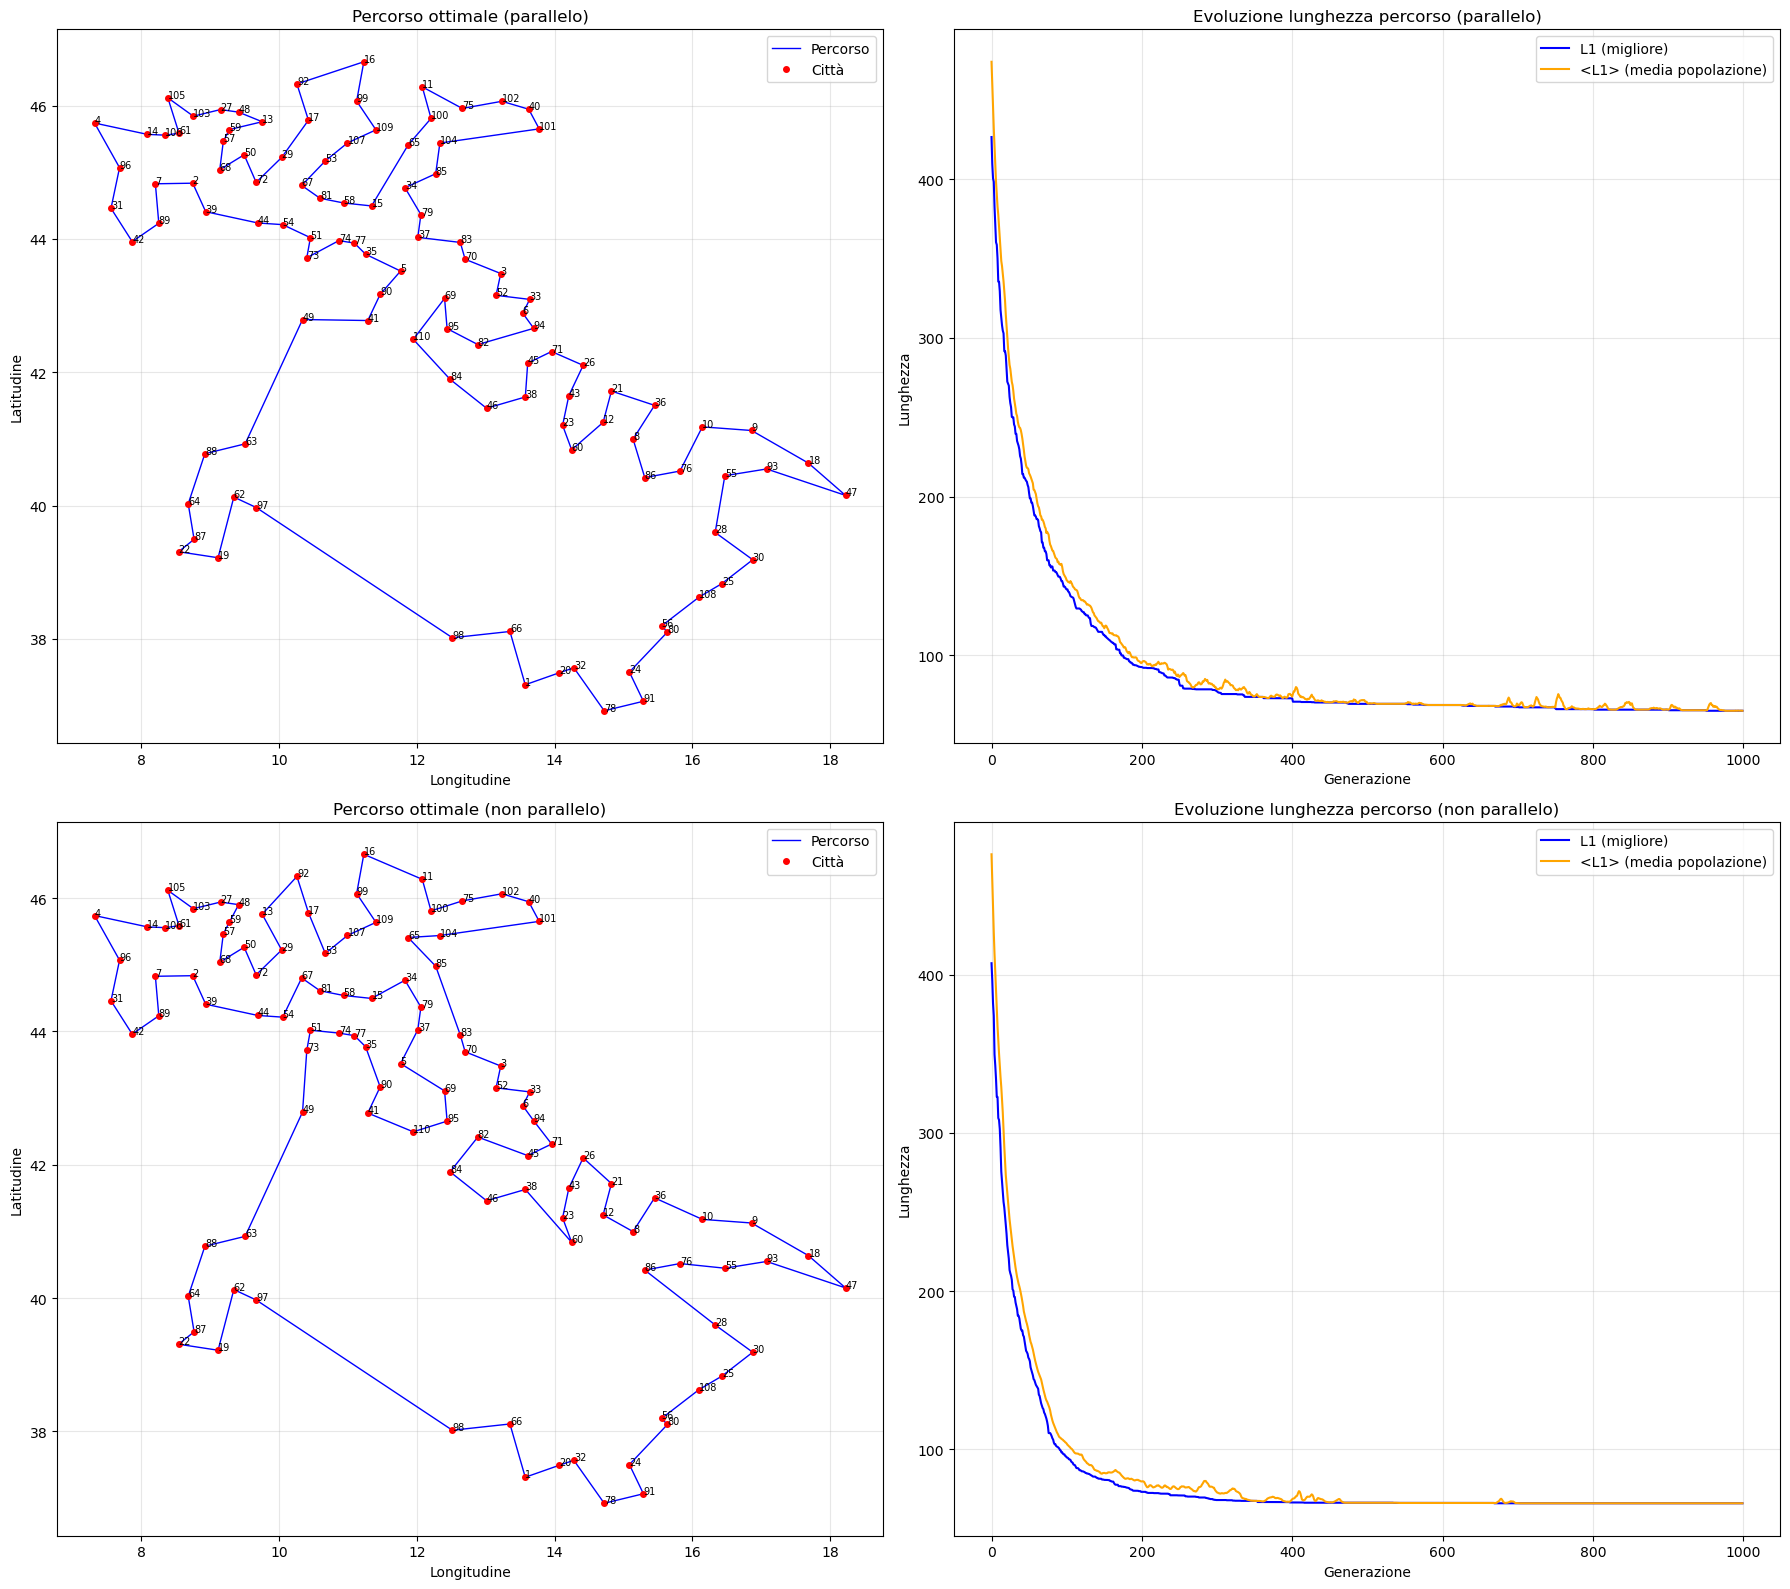

In [6]:
import matplotlib.pyplot as plt

def leggi_percorso(file):
    with open(file) as f:
        return [int(line.strip()) for line in f if line.strip() and not line.startswith('#')]

def leggi_coordinate(file):
    with open(file) as f:
        return [tuple(map(float, line.split())) for line in f if line.strip() and not line.startswith('#')]

def leggi_dati_evoluzione(file):
    generazioni, L1, L1_medio = [], [], []
    with open(file) as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                valori = line.split()
                generazioni.append(int(valori[0]))
                L1.append(float(valori[1]))
                L1_medio.append(float(valori[2]))
    return generazioni, L1, L1_medio

def disegna_confronto(coord_file, percorso_par, evol_par, percorso_nopar, evol_nopar):
    # Dati parallelo
    percorso1 = leggi_percorso(percorso_par)
    gen1, L1_1, L1m_1 = leggi_dati_evoluzione(evol_par)

    # Dati non parallelo
    percorso2 = leggi_percorso(percorso_nopar)
    gen2, L1_2, L1m_2 = leggi_dati_evoluzione(evol_nopar)

    # Coordinate comuni
    coordinate = leggi_coordinate(coord_file)

    def get_xy(percorso):
        x = [coordinate[i-1][0] for i in percorso]
        y = [coordinate[i-1][1] for i in percorso]
        x.append(x[0])
        y.append(y[0])
        return x, y

    x1, y1 = get_xy(percorso1)
    x2, y2 = get_xy(percorso2)

    fig, axs = plt.subplots(2, 2, figsize=(18, 16))

    # --- Parallelo: percorso
    axs[0, 0].plot(x1, y1, 'b-', linewidth=1, label='Percorso')
    axs[0, 0].plot(x1[:-1], y1[:-1], 'ro', markersize=4, label='Città')
    for i, (xi, yi) in enumerate(zip(x1[:-1], y1[:-1])):
        axs[0, 0].text(xi, yi, str(percorso1[i]), fontsize=7)
    axs[0, 0].set_title('Percorso ottimale (parallelo)')
    axs[0, 0].set_xlabel('Longitudine')
    axs[0, 0].set_ylabel('Latitudine')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # --- Parallelo: evoluzione
    axs[0, 1].plot(gen1, L1_1, label='L1 (migliore)', color='blue')
    axs[0, 1].plot(gen1, L1m_1, label='<L1> (media popolazione)', color='orange')
    axs[0, 1].set_title('Evoluzione lunghezza percorso (parallelo)')
    axs[0, 1].set_xlabel('Generazione')
    axs[0, 1].set_ylabel('Lunghezza')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # --- No parallelo: percorso
    axs[1, 0].plot(x2, y2, 'b-', linewidth=1, label='Percorso')
    axs[1, 0].plot(x2[:-1], y2[:-1], 'ro', markersize=4, label='Città')
    for i, (xi, yi) in enumerate(zip(x2[:-1], y2[:-1])):
        axs[1, 0].text(xi, yi, str(percorso2[i]), fontsize=7)
    axs[1, 0].set_title('Percorso ottimale (non parallelo)')
    axs[1, 0].set_xlabel('Longitudine')
    axs[1, 0].set_ylabel('Latitudine')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # --- No parallelo: evoluzione
    axs[1, 1].plot(gen2, L1_2, label='L1 (migliore)', color='blue')
    axs[1, 1].plot(gen2, L1m_2, label='<L1> (media popolazione)', color='orange')
    axs[1, 1].set_title('Evoluzione lunghezza percorso (non parallelo)')
    axs[1, 1].set_xlabel('Generazione')
    axs[1, 1].set_ylabel('Lunghezza')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()

    plt.tight_layout()
    plt.savefig('confronto_par_nopar.png', dpi=150)
    plt.show()

if __name__ == "__main__":
    disegna_confronto(
        "cap_prov_ita.dat",
        "./simulazioni-eseguite/par/global_best_route.dat",
        "./simulazioni-eseguite/par/results_5.dat",
        "./simulazioni-eseguite/nopar/global_best_route.dat",
        "./simulazioni-eseguite/nopar/results_0.dat"
    )


**Risultati ottenuti:**

| Numero di core    | $L^{(1)}$ migliore |
|-------------------|------------------|
| $12$              | 64.9286          |
| $1$               | 65.9858          |

Si osserva che, nonostante il numero di individui sia lo stesso, la parallelizzazione del codice e l'evoluzione indipendente di popolazioni diverse consente di ottenere un risultato migliore.